In [11]:
import sys
sys.path.append("../src")

import diff
import importlib

importlib.reload(diff)

print(dir(diff))

['PCA', 'StandardScaler', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'differential_expression', 'multipletests', 'np', 'pca_plot', 'pd', 'plt', 'ttest_ind', 'volcano_plot']


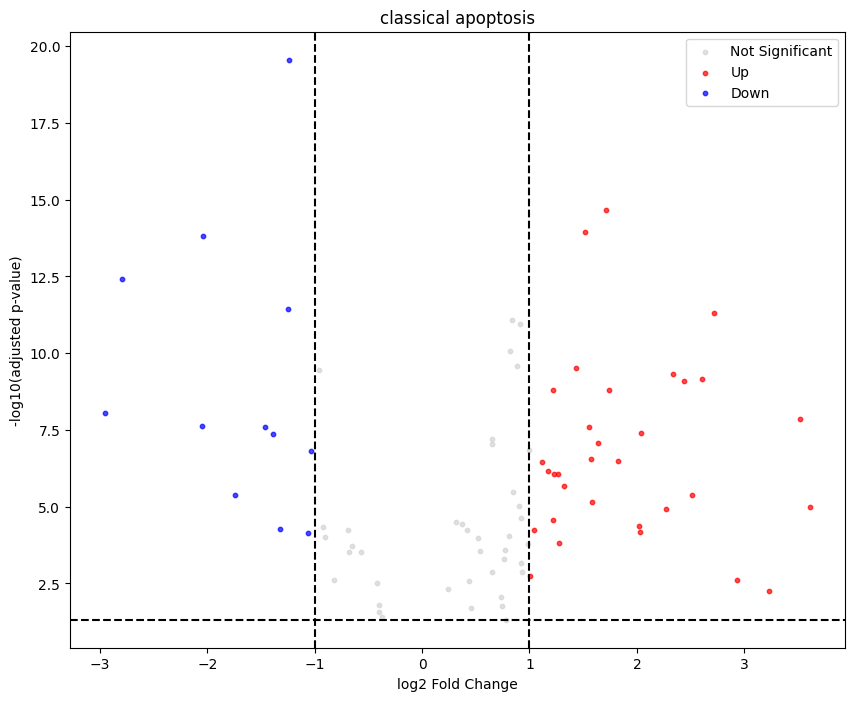

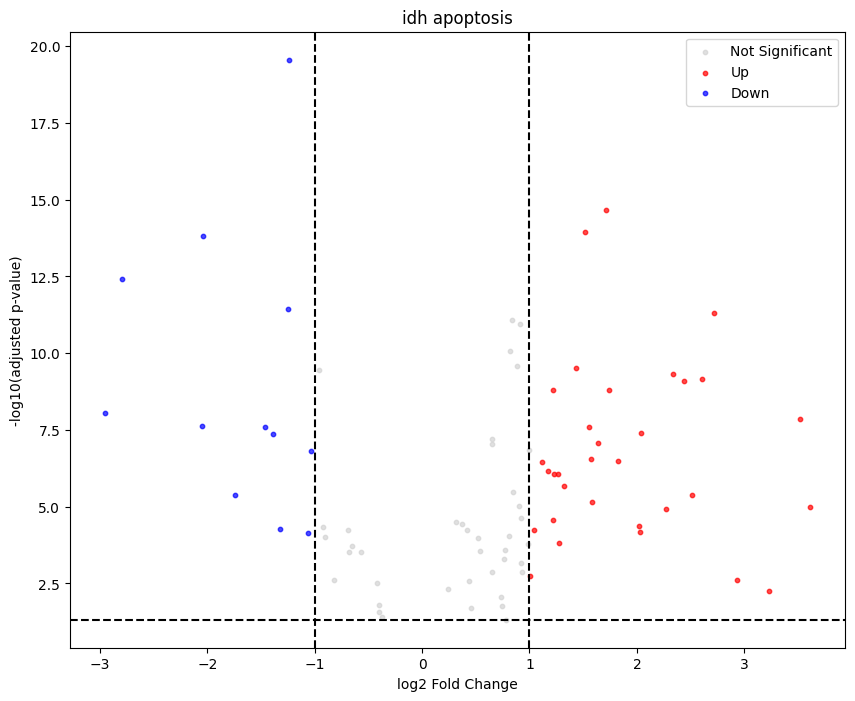

In [12]:
import pandas as pd
clas = pd.read_csv("../data/processed/pathway_diff/classical/classical_Apoptosis_diff.csv",index_col=0)[["log2FC_rna","-log(adjustedp)_rna","category_rna"]]
idh = pd.read_csv("../data/processed/pathway_diff/idh/idh_Apoptosis_diff.csv",index_col=0)[["log2FC_rna","-log(adjustedp)_rna","category_rna"]]

diff.volcano_plot(clas,'classical apoptosis')
diff.volcano_plot(idh,'idh apoptosis')

In [1]:
import pandas as pd
from pathlib import Path

subtypes = [
    "proneural",
    "classical",
    "mesenchymal",
    "idh"
]

input_dir = Path("../data/interim")
output_dir = Path("../data/processed/diff")

for subtype in subtypes:

    rna = pd.read_csv(
        input_dir / f"{subtype}_rna_diff.csv",
        index_col=0
    )

    prot = pd.read_csv(
        input_dir / f"{subtype}_pro_diff.csv",
        index_col=0
    )

    # Keep only genes present in both datasets
    common = rna.index.intersection(prot.index)

    combined = (
        rna.loc[common]
        .join(
            prot.loc[common],
            lsuffix="_rna",
            rsuffix="_prot"
        )
        .sort_index()
    )

    combined.to_csv(
        output_dir / f"{subtype}_combined.csv"
    )

    print(f"{subtype}: {combined.shape[0]} genes")

proneural: 10074 genes
classical: 10074 genes
mesenchymal: 10074 genes
idh: 10074 genes
